# 12.3.1 中性漂变与有限种群

## 学习目标与先修知识

由二项抽样解释漂变方差（variance）和规模效应。

先修：5.1 条件概率（conditional probability）与重复；12.2 频率变量。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

没有类型收益差时，有限种群的比例仍会上下波动。一条频率上升轨迹（trajectory）能证明适应吗？规模从50变成500时波动如何变化？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

四个后代依次用固定随机数 .1、.2、.8、.9 从 p=.5 抽样，手算两位类型0。

In [2]:
print('p=0.5，抽样[.1,.2,.8,.9] → 下一代类型0频率2/4。')

p=0.5，抽样[.1,.2,.8,.9] → 下一代类型0频率2/4。


## 模型假设

每位后代独立从同一 p 抽取类型，下一代恰有 N 人；无选择和变异。这是中性遗传漂变（genetic drift）的简化模型（model），不包含谱系、年龄或空间。重复实验记录 N、p 和种子。

## 数学解释与推导

若下一代类型0计数 $X\sim\operatorname{Binomial}(N,p)$，频率 $p'=X/N$ 的条件期望（expectation）为 $p$，条件方差为 $p(1-p)/N$。单次 $p'>p$ 不证明选择；规模增大使一步抽样标准差（standard deviation）按 $N^{-1/2}$ 缩小，但不使单条轨迹失去随机性。无变异时 $p=0,1$ 为吸收边界。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def neutral_step(p, draws):
    """One Wright-Fisher-style generation with supplied independent U[0,1) draws."""
    return sum(value < p for value in draws) / len(draws)

## 对照实验

固定 p=.3，对 N=50 和500 各重复300次；同时画经验分布（distribution）与解析标准差。

N 50 经验均值 0.3063 经验SD 0.065 理论SD 0.0648
N 500 经验均值 0.2999 经验SD 0.018 理论SD 0.0205


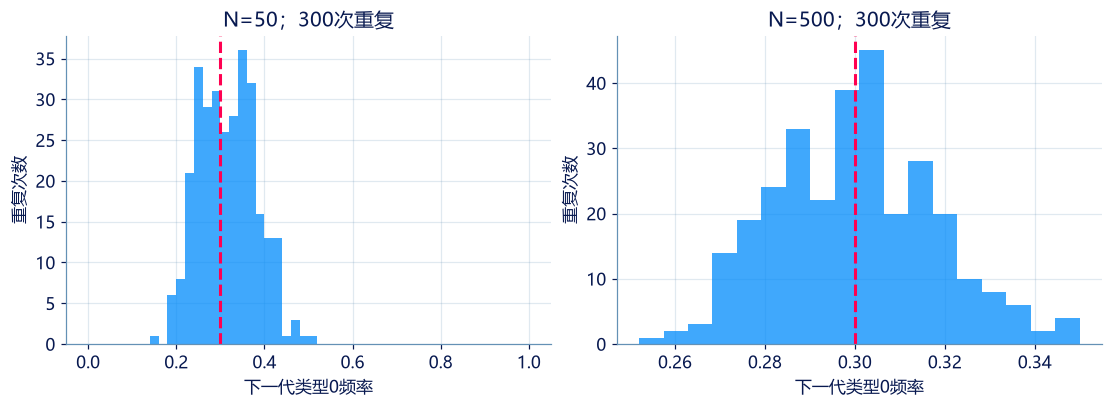

In [4]:
p=.3;R=300;rng=np.random.default_rng(1231);out={}
for N in [50,500]:
    out[N]=np.array([neutral_step(p,rng.random(N)) for _ in range(R)])
    print('N',N,'经验均值',round(out[N].mean(),4),'经验SD',round(out[N].std(),4),
          '理论SD',round(math.sqrt(p*(1-p)/N),4))
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
for ax,N in zip(axes,[50,500]):
    ax.hist(out[N],bins=np.arange(0,1.01,1/N) if N==50 else 18,color=BLUE,alpha=.75)
    ax.axvline(p,color=PINK,ls='--')
    ax.set(xlabel='下一代类型0频率',ylabel='重复次数',title=f'N={N}；300次重复')
plt.show()

## 结果解释

两个规模的经验中心接近 p，但有限重复仍有抽样误差；N=500 的单步分布更窄。在相同 p 下，较大种群的一步抽样波动较小。

### 独立核对

用独立二项理论方差和不可能事件（event）边界检验。

In [5]:
assert neutral_step(.5,[.1,.2,.8,.9])==.5
assert neutral_step(0.,[.1,.3])==0. and neutral_step(1.,[.1,.3])==1.
assert abs(out[50].var()-p*(1-p)/50)<.002
assert abs(out[500].var()-p*(1-p)/500)<.0002
print('最小抽样、吸收边界及规模方差核验通过。')

最小抽样、吸收边界及规模方差核验通过。


## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：用固定抽样表更新中性种群

二类型种群下一代有 len(draws) 个个体。每个预先给定的 U[0,1) 抽样值小于当前类型0频率 p 时记类型0。返回下一代类型0频率，阈值相等时不计入。

**函数与代码模板**

```python
def solve(
    p: float,
    draws: list[float],
) -> float:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `p` | `float` | 当前类型0频率。 | 1 |
| `draws` | `list[float]` | 独立均匀抽样值，长度等于下一代人数。 | 1 |

**返回值**

直接返回 next_frequency（float）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `next_frequency` | `float` | 下一代类型0频率。 | 1 |

**计算规则**

按 draw<p 计数并除以 N；本题不引入选择或变异。

**约束与边界**

- 只使用题定的有限状态（state）、固定输入（input）与明示更新规则；不从图形猜测答案。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| p | 当前类型0频率。 | 0.5 | 1 |
| draws | 独立均匀抽样值，长度等于下一代人数。 | [0.1, 0.2, 0.8, 0.9] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
p = 0.5
draws = [0.1, 0.2, 0.8, 0.9]

result = solve(p, draws)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| next_frequency | 下一代类型0频率。 | 0.5 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 0.5
```

**样例解释**

首例恰有2/4 类型0；第二例等于阈值的.5不计入。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：用固定抽样表更新中性种群](http://127.0.0.1:8000/chapters/12-03-%E9%80%89%E6%8B%A9%E3%80%81%E5%8F%98%E5%BC%82%E4%B8%8E%E9%80%82%E5%BA%94/practice/?question=p12-neutral-draws)

### 第 2 题 · 单项选择题：漂变方差与规模

中性二项抽样下一代人数 N，当前类型0频率 p。下一代频率条件方差（variance）为何？

- **A.** p(1−p)/N。
- **B.** Np(1−p)。
- **C.** p/N。
- **D.** 与 N 无关。

[作答：漂变方差与规模](http://127.0.0.1:8000/chapters/12-03-%E9%80%89%E6%8B%A9%E3%80%81%E5%8F%98%E5%BC%82%E4%B8%8E%E9%80%82%E5%BA%94/practice/?question=p12-neutral-variance)

### 第 3 题 · 单项选择题：一次频率上升

中性模型（model）某次 p 从0.5升至0.6，可否据此确认类型0有选择优势？

- **A.** 不能，固定条件下中性抽样也会波动。
- **B.** 能，任何上升都是适应。
- **C.** 能，因为 N 大于0。
- **D.** 只能说明变异率必为正。

[作答：一次频率上升](http://127.0.0.1:8000/chapters/12-03-%E9%80%89%E6%8B%A9%E3%80%81%E5%8F%98%E5%BC%82%E4%B8%8E%E9%80%82%E5%BA%94/practice/?question=p12-one-rise)

### 第 4 题 · 单项选择题：零变异的边界

有限中性模型（model）无变异，某代 p=0。下一代可能重新出现类型0吗？

- **A.** 不能；按本模型抽样概率（probability）仍为0。
- **B.** 必能。
- **C.** 只有 N=50 时能。
- **D.** 取决于图像颜色。

[作答：零变异的边界](http://127.0.0.1:8000/chapters/12-03-%E9%80%89%E6%8B%A9%E3%80%81%E5%8F%98%E5%BC%82%E4%B8%8E%E9%80%82%E5%BA%94/practice/?question=p12-neutral-absorption)

**进一步阅读**

[SFI Complexity Explorer 的复杂系统课程](https://www.complexityexplorer.org/courses/185-introduction-to-complexity/faq)涵盖随机演化主题；本节方差由二项模型直接推导。